```{contents}
```
# Transformer Network

Welcome to Week 4's assignment, the last assignment of Course 5 of the Deep Learning Specialization! And congratulations on making it to the last assignment of the entire Deep Learning Specialization - you're almost done!

Earlier in the course, you've implemented sequential neural networks such as RNNs, GRUs, and LSTMs. In this notebook you'll explore the Transformer architecture, a neural network that takes advantage of parallel processing and allows you to substantially speed up the training process. 

**After this assignment you'll be able to**:

* Create positional encodings to capture sequential relationships in data
* Calculate scaled dot-product self-attention with word embeddings
* Implement masked multi-head attention
* Build and train a Transformer model

For the last time, let's get started!

## Important Note on Submission to the AutoGrader

Before submitting your assignment to the AutoGrader, please make sure you are not doing the following:

1. You have not added any _extra_ `print` statement(s) in the assignment.
2. You have not added any _extra_ code cell(s) in the assignment.
3. You have not changed any of the function parameters.
4. You are not using any global variables inside your graded exercises. Unless specifically instructed to do so, please refrain from it and use the local variables instead.
5. You are not changing the assignment code where it is not required, like creating _extra_ variables.

If you do any of the following, you will get something like, `Grader Error: Grader feedback not found` (or similarly unexpected) error upon submitting your assignment. Before asking for help/debugging the errors in your assignment, check for these first. If this is the case, and you don't remember the changes you have made, you can get a fresh copy of the assignment by following these [instructions](https://www.coursera.org/learn/nlp-sequence-models/supplement/X39s5/optional-downloading-your-notebook-downloading-your-workspace-and-refreshing).

<a name='0'></a>
## Packages

Run the following cell to load the packages you'll need.

In [1]:
### v1.6

In [2]:
import tensorflow as tf
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Embedding, MultiHeadAttention, Dense, Input, Dropout, LayerNormalization

<a name='1'></a>
## 1 - Positional Encoding

In sequence to sequence tasks, the relative order of your data is extremely important to its meaning. When you were training sequential neural networks such as RNNs, you fed your inputs into the network in order. Information about the order of your data was automatically fed into your model.  However, when you train a Transformer network using multi-head attention, you feed your data into the model all at once. While this dramatically reduces training time, there is no information about the order of your data. This is where positional encoding is useful - you can specifically encode the positions of your inputs and pass them into the network using these sine and cosine formulas:
    
$$
PE_{(pos, 2i)}= sin\left(\frac{pos}{{10000}^{\frac{2i}{d}}}\right)
\tag{1}$$
<br>
$$
PE_{(pos, 2i+1)}= cos\left(\frac{pos}{{10000}^{\frac{2i}{d}}}\right)
\tag{2}$$

* $d$ is the dimension of the word embedding and positional encoding
* $pos$ is the position of the word.
* $k$ refers to each of the different dimensions in the positional encodings, with $i$ equal to $k$ $//$ $2$.

To develop some intuition about positional encodings, you can think of them broadly as a feature that contains the information about the relative positions of words. The sum of the positional encoding and word embedding is ultimately what is fed into the model. If you just hard code the positions in, say by adding a matrix of 1's or whole numbers to the word embedding, the semantic meaning is distorted. Conversely, the values of the sine and cosine equations are small enough (between -1 and 1) that when you add the positional encoding to a word embedding, the word embedding is not significantly distorted, and is instead enriched with positional information. Using a combination of these two equations helps your Transformer network attend to the relative positions of your input data. This was a short discussion on positional encodings, but to develop further intuition, check out the *Positional Encoding Ungraded Lab*. 

**Note:** In the lectures Andrew uses vertical vectors, but in this assignment all vectors are horizontal. All matrix multiplications should be adjusted accordingly.

<a name='1-1'></a>
### 1.1 - Sine and Cosine Angles

Notice that even though the sine and cosine positional encoding equations take in different arguments (`2i` versus `2i+1`, or even versus odd numbers) the inner terms for both equations are the same: $$\theta(pos, i, d) = \frac{pos}{10000^{\frac{2i}{d}}} \tag{3}$$

Consider the inner term as you calculate the positional encoding for a word in a sequence.<br> 
$PE_{(pos, 0)}= sin\left(\frac{pos}{{10000}^{\frac{0}{d}}}\right)$, since solving `2i = 0` gives `i = 0` <br>
$PE_{(pos, 1)}= cos\left(\frac{pos}{{10000}^{\frac{0}{d}}}\right)$, since solving `2i + 1 = 1` gives `i = 0`

The angle is the same for both! The angles for $PE_{(pos, 2)}$ and $PE_{(pos, 3)}$ are the same as well, since for both, `i = 1` and therefore the inner term is $\left(\frac{pos}{{10000}^{\frac{2}{d}}}\right)$. This relationship holds true for all paired sine and cosine curves:

|      k         | <code>       0      </code>|<code>       1      </code>|<code>       2      </code>|<code>       3      </code>| <code> ... </code> |<code>      d - 2     </code>|<code>      d - 1     </code>| 
| ---------------- | :------: | ----------------- | ----------------- | ----------------- | ----- | ----------------- | ----------------- |
| encoding(0) = |[$sin(\theta(0, 0, d))$| $cos(\theta(0, 0, d))$| $sin(\theta(0, 1, d))$| $cos(\theta(0, 1, d))$|... |$sin(\theta(0, d//2, d))$| $cos(\theta(0, d//2, d))$]|
| encoding(1) = | [$sin(\theta(1, 0, d))$| $cos(\theta(1, 0, d))$| $sin(\theta(1, 1, d))$| $cos(\theta(1, 1, d))$|... |$sin(\theta(1, d//2, d))$| $cos(\theta(1, d//2, d))$]|
...
| encoding(pos) = | [$sin(\theta(pos, 0, d))$| $cos(\theta(pos, 0, d))$| $sin(\theta(pos, 1, d))$| $cos(\theta(pos, 1, d))$|... |$sin(\theta(pos, d//2, d))$| $cos(\theta(pos, d//2, d))]$|


<a name='ex-1'></a>
### Exercise 1 - get_angles

Implement the function `get_angles()` to calculate the possible angles for the sine and cosine positional encodings

**Hints**

- If `k = [0, 1, 2, 3, 4, 5]`, then, `i` must be `i = [0, 0, 1, 1, 2, 2]`
- `i = k//2`

In [3]:
# UNQ_C1 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: get_angles
import numpy as np

def get_angles(pos, k, d):
    """
    Get the angles for the positional encoding
    
    Arguments:
        pos -- Column vector containing the positions [[0], [1], ...,[N-1]] (shape: [N, 1])
        k -- Row vector containing the dimension span [[0, 1, 2, ..., d-1]] (shape: [1, d])
        d -- Integer, encoding dimension
    
    Returns:
        angles -- (pos, d) numpy array of computed angles
    """
    
    ### START CODE HERE ###
    # i is just k (the dimension indices)
    i = k

    # Compute the angles as defined in the Transformer paper
    # angle_rates = pos / (10000^(2*(i//2)/d))
    angles = pos / np.power(10000, (2 * (i // 2)) / np.float32(d))
    ### END CODE HERE ###
    
    return angles


In [4]:
from public_tests import *

get_angles_test(get_angles)

# Example
position = 4
d_model = 8
pos_m = np.arange(position)[:, np.newaxis]
dims = np.arange(d_model)[np.newaxis, :]
get_angles(pos_m, dims, d_model)

All tests passed


array([[0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
       [1.e+00, 1.e+00, 1.e-01, 1.e-01, 1.e-02, 1.e-02, 1.e-03, 1.e-03],
       [2.e+00, 2.e+00, 2.e-01, 2.e-01, 2.e-02, 2.e-02, 2.e-03, 2.e-03],
       [3.e+00, 3.e+00, 3.e-01, 3.e-01, 3.e-02, 3.e-02, 3.e-03, 3.e-03]])

<a name='1-2'></a>
### 1.2 - Sine and Cosine Positional Encodings

Now you can use the angles you computed to calculate the sine and cosine positional encodings.

$$
PE_{(pos, 2i)}= sin\left(\frac{pos}{{10000}^{\frac{2i}{d}}}\right)
$$
<br>
$$
PE_{(pos, 2i+1)}= cos\left(\frac{pos}{{10000}^{\frac{2i}{d}}}\right)
$$

<a name='ex-2'></a>
### Exercise 2 - positional_encoding

Implement the function `positional_encoding()` to calculate the sine and cosine  positional encodings

**Reminder:** Use the sine equation when $i$ is an even number and the cosine equation when $i$ is an odd number.

#### Additional Hints
* You may find 
[np.newaxis](https://numpy.org/doc/stable/user/basics.indexing.html#dimensional-indexing-tools) useful depending on the implementation you choose. 

In [5]:
# UNQ_C2 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: positional_encoding

import numpy as np
import tensorflow as tf

def positional_encoding(positions, d):
    """
    Precomputes a matrix with all the positional encodings.
    
    Arguments:
        positions (int) -- Maximum number of positions to be encoded 
        d (int) -- Encoding size 
    
    Returns:
        pos_encoding -- (1, positions, d) A matrix with the positional encodings
    """
    ### START CODE HERE ###
    # Step 1: Compute the angle matrix
    pos = np.arange(positions)[:, np.newaxis]      # shape (positions, 1)
    k = np.arange(d)[np.newaxis, :]                # shape (1, d)
    angle_rads = get_angles(pos, k, d)             # shape (positions, d)
  
    # Step 2: Apply sin to even indices (2i)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
  
    # Step 3: Apply cos to odd indices (2i+1)
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    ### END CODE HERE ###
    
    # Step 4: Add batch dimension
    pos_encoding = angle_rads[np.newaxis, ...]
    
    return tf.cast(pos_encoding, dtype=tf.float32)


In [6]:
# UNIT TEST    
positional_encoding_test(positional_encoding, get_angles)

All tests passed


Nice work calculating the positional encodings! Now you can visualize them.

(1, 50, 512)


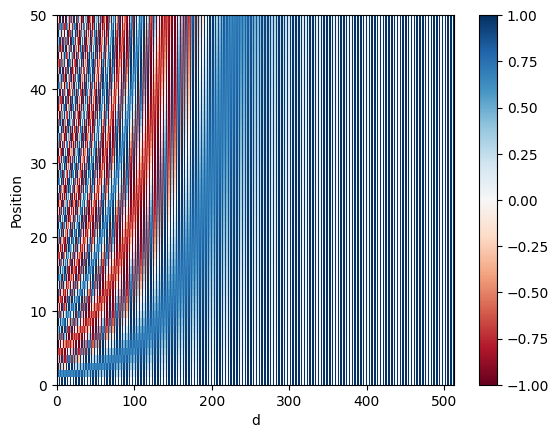

In [7]:
pos_encoding = positional_encoding(50, 512)

print (pos_encoding.shape)

plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('d')
plt.xlim((0, 512))
plt.ylabel('Position')
plt.colorbar()
plt.show()

Each row represents a positional encoding - notice how none of the rows are identical! You have created a unique positional encoding for each of the words.

<a name='2'></a>
## 2 - Masking

There are two types of masks that are useful when building your Transformer network: the *padding mask* and the *look-ahead mask*. Both help the softmax computation give the appropriate weights to the words in your input sentence. 

<a name='2-1'></a>
### 2.1 - Padding Mask

Oftentimes your input sequence will exceed the maximum length of a sequence your network can process. Let's say the maximum length of your model is five, it is fed the following sequences:

    [["Do", "you", "know", "when", "Jane", "is", "going", "to", "visit", "Africa"], 
     ["Jane", "visits", "Africa", "in", "September" ],
     ["Exciting", "!"]
    ]

which might get vectorized as:

    [[ 71, 121, 4, 56, 99, 2344, 345, 1284, 15],
     [ 56, 1285, 15, 181, 545],
     [ 87, 600]
    ]
    
When passing sequences into a transformer model, it is important that they are of uniform length. You can achieve this by padding the sequence with zeros, and truncating sentences that exceed the maximum length of your model:

    [[ 71, 121, 4, 56, 99],
     [ 2344, 345, 1284, 15, 0],
     [ 56, 1285, 15, 181, 545],
     [ 87, 600, 0, 0, 0],
    ]
    
Sequences longer than the maximum length of five will be truncated, and zeros will be added to the truncated sequence to achieve uniform length. Similarly, for sequences shorter than the maximum length, zeros will also be added for padding. However, these zeros will affect the softmax calculation - this is when a padding mask comes in handy! You will need to define a boolean mask that specifies to which elements you must attend(1) and which elements you must ignore(0). Later you will use that mask to set all the zeros in the sequence to a value close to negative infinity (-1e9). We'll implement this for you so you can get to the fun of building the Transformer network! 😇 Just make sure you go through the code so you can correctly implement padding when building your model. 

After masking, your input should go from `[87, 600, 0, 0, 0]` to `[87, 600, -1e9, -1e9, -1e9]`, so that when you take the softmax, the zeros don't affect the score.

The [MultiheadAttention](https://keras.io/api/layers/attention_layers/multi_head_attention/) layer implemented in Keras, uses this masking logic.

**Note:** The below function only creates the mask of an _already padded sequence_. Later in this week, you’ll go through some Labs on Transformer applications, where you’ll be introduced to [TensorFlow Tokenizer](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) and [Hugging Face Tokenizer](https://huggingface.co/docs/tokenizers/api/tokenizer), which internally handle padding (and truncating) the input sequence.

In [8]:
def create_padding_mask(decoder_token_ids):
    """
    Creates a matrix mask for the padding cells
    
    Arguments:
        decoder_token_ids -- (n, m) matrix
    
    Returns:
        mask -- (n, 1, m) binary tensor
    """    
    seq = 1 - tf.cast(tf.math.equal(decoder_token_ids, 0), tf.float32)
  
    # add extra dimensions to add the padding
    # to the attention logits. 
    # this will allow for broadcasting later when comparing sequences
    return seq[:, tf.newaxis, :] 

In [9]:
x = tf.constant([[7., 6., 0., 0., 1.], [1., 2., 3., 0., 0.], [0., 0., 0., 4., 5.]])
print(create_padding_mask(x))

tf.Tensor(
[[[1. 1. 0. 0. 1.]]

 [[1. 1. 1. 0. 0.]]

 [[0. 0. 0. 1. 1.]]], shape=(3, 1, 5), dtype=float32)


If we multiply (1 - mask) by -1e9 and add it to the sample input sequences, the zeros are essentially set to negative infinity. Notice the difference when taking the softmax of the original sequence and the masked sequence:

In [10]:
print(tf.keras.activations.softmax(x))
print(tf.keras.activations.softmax(x + (1 - create_padding_mask(x)) * -1.0e9))

tf.Tensor(
[[7.2876638e-01 2.6809821e-01 6.6454895e-04 6.6454895e-04 1.8064313e-03]
 [8.4437370e-02 2.2952458e-01 6.2391245e-01 3.1062771e-02 3.1062771e-02]
 [4.8541022e-03 4.8541022e-03 4.8541022e-03 2.6502505e-01 7.2041267e-01]], shape=(3, 5), dtype=float32)
tf.Tensor(
[[[7.2973621e-01 2.6845497e-01 0.0000000e+00 0.0000000e+00 1.8088353e-03]
  [2.4472848e-01 6.6524088e-01 0.0000000e+00 0.0000000e+00 9.0030566e-02]
  [6.6483538e-03 6.6483538e-03 0.0000000e+00 0.0000000e+00 9.8670328e-01]]

 [[7.3057157e-01 2.6876229e-01 6.6619506e-04 0.0000000e+00 0.0000000e+00]
  [9.0030566e-02 2.4472848e-01 6.6524088e-01 0.0000000e+00 0.0000000e+00]
  [3.3333334e-01 3.3333334e-01 3.3333334e-01 0.0000000e+00 0.0000000e+00]]

 [[0.0000000e+00 0.0000000e+00 0.0000000e+00 2.6894143e-01 7.3105854e-01]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 5.0000000e-01 5.0000000e-01]
  [0.0000000e+00 0.0000000e+00 0.0000000e+00 2.6894143e-01 7.3105854e-01]]], shape=(3, 3, 5), dtype=float32)


<a name='2-2'></a>
### 2.2 - Look-ahead Mask

The look-ahead mask follows similar intuition. In training, you will have access to the complete correct output of your training example. The look-ahead mask helps your model pretend that it correctly predicted a part of the output and see if, *without looking ahead*, it can correctly predict the next output. 

For example, if the expected correct output is `[1, 2, 3]` and you wanted to see if given that the model correctly predicted the first value it could predict the second value, you would mask out the second and third values. So you would input the masked sequence `[1, -1e9, -1e9]` and see if it could generate `[1, 2, -1e9]`.

Just because you've worked so hard, we'll also implement this mask for you 😇😇. Again, take a close look at the code so you can effectively implement it later.

In [11]:
def create_look_ahead_mask(sequence_length):
    """
    Returns a lower triangular matrix filled with ones
    
    Arguments:
        sequence_length -- matrix size
    
    Returns:
        mask -- (size, size) tensor
    """
    mask = tf.linalg.band_part(tf.ones((1, sequence_length, sequence_length)), -1, 0)
    return mask 

In [12]:
x = tf.random.uniform((1, 3))
temp = create_look_ahead_mask(x.shape[1])
temp

<tf.Tensor: shape=(1, 3, 3), dtype=float32, numpy=
array([[[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]]], dtype=float32)>

<a name='3'></a>
## 3 - Self-Attention

As the authors of the Transformers paper state, "Attention is All You Need". 

<img src="../../assets/C5_W4/images/self-attention.png" alt="Encoder" width="600"/>
<caption><center><font color='purple'><b>Figure 1: Self-Attention calculation visualization</font></center></caption>
    
The use of self-attention paired with traditional convolutional networks allows for parallelization which speeds up training. You will implement **scaled dot product attention** which takes in a query, key, value, and a mask as inputs to return rich, attention-based vector representations of the words in your sequence. This type of self-attention can be mathematically expressed as:
$$
\text { Attention }(Q, K, V)=\operatorname{softmax}\left(\frac{Q K^{T}}{\sqrt{d_{k}}}+{M}\right) V\tag{4}\
$$

* $Q$ is the matrix of queries 
* $K$ is the matrix of keys
* $V$ is the matrix of values
* $M$ is the optional mask you choose to apply 
* ${d_k}$ is the dimension of the keys, which is used to scale everything down so the softmax doesn't explode

<a name='ex-3'></a>

### Exercise 3 - scaled_dot_product_attention 

Implement the function `scaled_dot_product_attention()` to create attention-based representations.

**Reminder**: The boolean mask parameter can be passed in as `none` or as either padding or look-ahead. 
    
    Multiply (1. - mask) by -1e9 before applying the softmax. 

**Additional Hints**
* You may find [tf.matmul](https://www.tensorflow.org/api_docs/python/tf/linalg/matmul) useful for matrix multiplication.

In [13]:
# UNQ_C3 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: scaled_dot_product_attention

import tensorflow as tf

def scaled_dot_product_attention(q, k, v, mask):
    """
    Calculate the scaled dot-product attention.
    
    Arguments:
        q -- query tensor (..., seq_len_q, depth)
        k -- key tensor (..., seq_len_k, depth)
        v -- value tensor (..., seq_len_v, depth_v)
        mask -- (optional) Float tensor broadcastable to (..., seq_len_q, seq_len_k)
                Used to mask out padding tokens or future positions in decoding.

    Returns:
        output -- attention output (..., seq_len_q, depth_v)
        attention_weights -- attention weights (..., seq_len_q, seq_len_k)
    """
    ### START CODE HERE ###
    # Step 1: MatMul Q and K^T
    matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

    # Step 2: Scale matmul_qk
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # Step 3: Add mask (if provided)
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)  # large negative number → masked positions ≈ 0 after softmax

    # Step 4: Softmax over last axis (seq_len_k)
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

    # Step 5: Multiply weights by values
    output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)
    ### END CODE HERE ###

    return output, attention_weights


In [14]:
# UNIT TEST
# scaled_dot_product_attention_test(scaled_dot_product_attention)

Excellent work! You can now implement self-attention. With that, you can start building the encoder block! 

<a name='4'></a>
## 4 - Encoder

The Transformer Encoder layer pairs self-attention and convolutional neural network style of processing to improve the speed of training and passes K and V matrices to the Decoder, which you'll build later in the assignment. In this section of the assignment, you will implement the Encoder by pairing multi-head attention and a feed forward neural network (Figure 2a). 
<img src="../../assets/C5_W4/images/encoder_layer.png" alt="Encoder" width="400"/>
<caption><center><font color='purple'><b>Figure 2a: Transformer encoder layer</font></center></caption>

* `MultiHeadAttention` you can think of as computing the self-attention several times to detect different features. 
* Feed forward neural network contains two Dense layers which we'll implement as the function `FullyConnected`

Your input sentence first passes through a *multi-head attention layer*, where the encoder looks at other words in the input sentence as it encodes a specific word. The outputs of the multi-head attention layer are then fed to a *feed forward neural network*. The exact same feed forward network is independently applied to each position.
   
* For the `MultiHeadAttention` layer, you will use the [Keras implementation](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention). If you're curious about how to split the query matrix Q, key matrix K, and value matrix V into different heads, you can look through the implementation. 
* You will also use the [Sequential API](https://keras.io/api/models/sequential/) with two dense layers to built the feed forward neural network layers.
    
**Note:** In Python, the `__call__` method allows you to call an object like a function. TensorFlow leverages this by providing a `call` function within Keras layers.  This means you can use a layer like `a_Layer(arg)` and TensorFlow will internally execute `a_Layer.call(arg)` to process your data.  This design makes it intuitive to apply layers within your TensorFlow models.    

In [15]:
def FullyConnected(embedding_dim, fully_connected_dim):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(fully_connected_dim, activation='relu'),  # (batch_size, seq_len, dff)
        tf.keras.layers.Dense(embedding_dim)  # (batch_size, seq_len, embedding_dim)
    ])

<a name='4-1'></a>
### 4.1 Encoder Layer

Now you can pair multi-head attention and feed forward neural network together in an encoder layer! You will also use residual connections and layer normalization to help speed up training (Figure 2a).

<a name='ex-4'></a>
### Exercise 4 - EncoderLayer

Implement `EncoderLayer()` using the `call()` method

In this exercise, you will implement one encoder block (Figure 2) using the `call()` method. The function should perform the following steps: 
1. You will pass the Q, V, K matrices and a boolean mask to a multi-head attention layer. Remember that to compute *self*-attention Q, V and K should be the same. Set the default values for `return_attention_scores` and `training`. You will also perform Dropout in this multi-head attention layer during training. 
2. Now add a skip connection by adding your original input `x` and the output of the your multi-head attention layer. 
3. After adding the skip connection, pass the output through the first normalization layer.
4. Finally, repeat steps 1-3 but with the feed forward neural network with a dropout layer instead of the multi-head attention layer. 

<details>
  <summary><font size="2" color="darkgreen"><b>Additional Hints (Click to expand)</b></font></summary>
    
* The `__init__` method creates all the layers that will be accesed by the the `call` method. Wherever you want to use a layer defined inside  the `__init__`  method you will have to use the syntax `self.[insert layer name]`. 
* You will find the documentation of [MultiHeadAttention](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MultiHeadAttention) helpful. *Note that if query, key and value are the same, then this function performs self-attention.*
* The call arguments for `self.mha` are (Where B is for batch_size, T is for target sequence shapes, and S is output_shape):
 - `query`: Query Tensor of shape (B, T, dim).
 - `value`: Value Tensor of shape (B, S, dim).
 - `key`: Optional key Tensor of shape (B, S, dim). If not given, will use value for both key and value, which is the most common case.
 - `attention_mask`: a boolean mask of shape (B, T, S), that prevents attention to certain positions. The boolean mask specifies which query elements can attend to which key elements, 1 indicates attention and 0 indicates no attention. Broadcasting can happen for the missing batch dimensions and the head dimension.
 - `return_attention_scores`: A boolean to indicate whether the output should be (attention_output, attention_scores) if True, or attention_output if False. Defaults to False.
 - `training`: Python boolean indicating whether the layer should behave in training mode (adding dropout) or in inference mode (no dropout). Defaults to either using the training mode of the parent layer/model, or False (inference) if there is no parent layer. Take a look at [tf.keras.layers.Dropout](https://www.tensorflow.org/versions/r2.4/api_docs/python/tf/keras/layers/Dropout) for more details (Additional reading in [Keras FAQ](https://keras.io/getting_started/faq/#whats-the-difference-between-the-training-argument-in-call-and-the-trainable-attribute))

In [16]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: EncoderLayer

import tensorflow as tf
from tensorflow.keras.layers import LayerNormalization, Dropout, MultiHeadAttention

class EncoderLayer(tf.keras.layers.Layer):
    """
    The encoder layer consists of:
    - Multi-head self-attention
    - Feed-forward network (position-wise dense)
    Each sublayer includes residual connection + layer normalization.
    """
    def __init__(self, embedding_dim, num_heads, fully_connected_dim,
                 dropout_rate=0.1, layernorm_eps=1e-6):
        super(EncoderLayer, self).__init__()

        # Multi-head attention
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim,
            dropout=dropout_rate
        )

        # Feed-forward network (custom defined elsewhere)
        self.ffn = FullyConnected(
            embedding_dim=embedding_dim,
            fully_connected_dim=fully_connected_dim
        )

        # Layer normalizations
        self.layernorm1 = LayerNormalization(epsilon=layernorm_eps)
        self.layernorm2 = LayerNormalization(epsilon=layernorm_eps)

        # Dropout after feed-forward
        self.dropout_ffn = Dropout(dropout_rate)
    
    def call(self, x, training, mask):
        """
        Forward pass for the Encoder Layer
        
        Arguments:
            x -- Tensor of shape (batch_size, input_seq_len, embedding_dim)
            training -- Boolean, for dropout layers
            mask -- Boolean mask tensor to ignore padded tokens

        Returns:
            encoder_layer_out -- Tensor of shape (batch_size, input_seq_len, embedding_dim)
        """
        ### START CODE HERE ###

        # Step 1: Multi-head self-attention
        self_mha_output = self.mha(
            query=x, key=x, value=x, attention_mask=mask, training=training
        )  # (batch_size, input_seq_len, embedding_dim)

        # Step 2: Add & normalize (residual connection)
        skip_x_attention = self.layernorm1(x + self_mha_output)

        # Step 3: Feed-forward network
        ffn_output = self.ffn(skip_x_attention)  # (batch_size, input_seq_len, embedding_dim)

        # Step 4: Dropout
        ffn_output = self.dropout_ffn(ffn_output, training=training)

        # Step 5: Add & normalize (final output)
        encoder_layer_out = self.layernorm2(skip_x_attention + ffn_output)
        ### END CODE HERE ###

        return encoder_layer_out


In [17]:
# UNIT TEST
# EncoderLayer_test(EncoderLayer)

<a name='4-2'></a>
### 4.2 - Full Encoder

Awesome job! You have now successfully implemented positional encoding, self-attention, and an encoder layer - give yourself a pat on the back. Now you're ready to build the full Transformer Encoder (Figure 2b), where you will embed your input and add the positional encodings you calculated. You will then feed your encoded embeddings to a stack of Encoder layers. 

<img src="../../assets/C5_W4/images/encoder.png" alt="Encoder" width="330"/>
<caption><center><font color='purple'><b>Figure 2b: Transformer Encoder</font></center></caption>


<a name='ex-5'></a>
### Exercise 5 - Encoder

Complete the `Encoder()` function using the `call()` method to embed your input, add positional encoding, and implement multiple encoder layers. 

In this exercise, you will initialize your Encoder with an Embedding layer, positional encoding, and multiple EncoderLayers. Your `call()` method will perform the following steps: 
1. Pass your input through the Embedding layer.
2. Scale your embedding by multiplying it by the square root of your embedding dimension. Remember to cast the embedding dimension to data type `tf.float32` before computing the square root.
3. Add the position encoding: self.pos_encoding `[:, :seq_len, :]` to your embedding.
4. Pass the encoded embedding through a dropout layer, remembering to use the `training` parameter to set the model training mode. 
5. Pass the output of the dropout layer through the stack of encoding layers using a for loop.

In [18]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: Encoder

import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dropout

class Encoder(tf.keras.layers.Layer):
    """
    The entire Encoder:
      - Embedding + positional encoding
      - Stack of N identical EncoderLayers
    """
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim,
                 input_vocab_size, maximum_position_encoding,
                 dropout_rate=0.1, layernorm_eps=1e-6):
        super(Encoder, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_layers = num_layers

        # Step 1: Token Embedding
        self.embedding = Embedding(input_vocab_size, self.embedding_dim)

        # Step 2: Positional Encoding
        self.pos_encoding = positional_encoding(maximum_position_encoding, self.embedding_dim)

        # Step 3: Stack of Encoder Layers
        self.enc_layers = [
            EncoderLayer(
                embedding_dim=self.embedding_dim,
                num_heads=num_heads,
                fully_connected_dim=fully_connected_dim,
                dropout_rate=dropout_rate,
                layernorm_eps=layernorm_eps
            )
            for _ in range(self.num_layers)
        ]

        # Step 4: Dropout
        self.dropout = Dropout(dropout_rate)
        
    def call(self, x, training, mask):
        """
        Forward pass for the Encoder.
        
        Arguments:
            x -- (batch_size, input_seq_len)
            training -- Boolean, enables dropout
            mask -- Boolean mask to avoid attending to padding tokens
        
        Returns:
            x -- (batch_size, input_seq_len, embedding_dim)
        """
        seq_len = tf.shape(x)[1]
        
        ### START CODE HERE ###
        # Step 1: Token Embedding
        x = self.embedding(x)  # (batch_size, input_seq_len, embedding_dim)

        # Step 2: Scale embeddings
        x *= tf.math.sqrt(tf.cast(self.embedding_dim, tf.float32))

        # Step 3: Add positional encoding
        x += self.pos_encoding[:, :seq_len, :]

        # Step 4: Apply dropout
        x = self.dropout(x, training=training)

        # Step 5: Pass through N encoder layers
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)
        ### END CODE HERE ###

        return x  # (batch_size, input_seq_len, embedding_dim)


In [19]:
# UNIT TEST    
# Encoder_test(Encoder)

<a name='5'></a>
## 5 - Decoder

The Decoder layer takes the K and V matrices generated by the Encoder and computes the second multi-head attention layer with the Q matrix from the output (Figure 3a).

<img src="../../assets/C5_W4/images/decoder_layer.png" alt="Encoder" width="250"/>
<caption><center><font color='purple'><b>Figure 3a: Transformer Decoder layer</font></center></caption>

<a name='5-1'></a>    
### 5.1 - Decoder Layer
Again, you'll pair multi-head attention with a feed forward neural network, but this time you'll implement two multi-head attention layers. You will also use residual connections and layer normalization to help speed up training (Figure 3a).

<a name='ex-6'></a>    
### Exercise 6 - DecoderLayer
    
Implement `DecoderLayer()` using the `call()` method
    
1. Block 1 is a multi-head attention layer with a residual connection, and look-ahead mask. Like in the `EncoderLayer`, Dropout is defined within the multi-head attention layer.
2. Block 2 will take into account the output of the Encoder, so the multi-head attention layer will receive K and V from the encoder, and Q from the Block 1. You will then apply a normalization layer and a residual connection, just like you did before with the `EncoderLayer`.
3. Finally, Block 3 is a feed forward neural network with dropout and normalization layers and a residual connection.
    
**Additional Hints:**
* The first two blocks are fairly similar to the EncoderLayer except you will return `attention_scores` when computing self-attention

In [20]:
# UNQ_C6 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: DecoderLayer

import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout

class DecoderLayer(tf.keras.layers.Layer):
    """
    The decoder layer is composed of:
      1. Masked multi-head self-attention (for autoregressive generation)
      2. Encoder–decoder multi-head attention (attending to encoder outputs)
      3. Feed-forward network
    Each sublayer includes a residual connection and layer normalization.
    """
    def __init__(self, embedding_dim, num_heads, fully_connected_dim, dropout_rate=0.1, layernorm_eps=1e-6):
        super(DecoderLayer, self).__init__()

        # Block 1: Masked Multi-Head Self-Attention
        self.mha1 = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim,
            dropout=dropout_rate
        )

        # Block 2: Encoder–Decoder Multi-Head Attention
        self.mha2 = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embedding_dim,
            dropout=dropout_rate
        )

        # Block 3: Feed-Forward Network
        self.ffn = FullyConnected(
            embedding_dim=embedding_dim,
            fully_connected_dim=fully_connected_dim
        )

        # Layer Normalization for each sublayer
        self.layernorm1 = LayerNormalization(epsilon=layernorm_eps)
        self.layernorm2 = LayerNormalization(epsilon=layernorm_eps)
        self.layernorm3 = LayerNormalization(epsilon=layernorm_eps)

        # Dropout for the FFN output
        self.dropout_ffn = Dropout(dropout_rate)
    
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        """
        Forward pass for the Decoder Layer
        
        Arguments:
            x -- (batch_size, target_seq_len, embedding_dim)
            enc_output -- (batch_size, input_seq_len, embedding_dim)
            training -- Boolean, enables dropout during training
            look_ahead_mask -- mask to prevent attending to future positions
            padding_mask -- mask to ignore encoder padding tokens
        
        Returns:
            out3 -- (batch_size, target_seq_len, embedding_dim)
            attn_weights_block1 -- attention weights from first MHA
            attn_weights_block2 -- attention weights from second MHA
        """
        
        ### START CODE HERE ###
        # BLOCK 1: Masked Multi-Head Self-Attention
        mult_attn_out1, attn_weights_block1 = self.mha1(
            query=x, key=x, value=x, attention_mask=look_ahead_mask, 
            return_attention_scores=True, training=training
        )
        Q1 = self.layernorm1(x + mult_attn_out1)

        # BLOCK 2: Encoder–Decoder Multi-Head Attention
        mult_attn_out2, attn_weights_block2 = self.mha2(
            query=Q1, key=enc_output, value=enc_output, attention_mask=padding_mask, 
            return_attention_scores=True, training=training
        )
        mult_attn_out2 = self.layernorm2(Q1 + mult_attn_out2)

        # BLOCK 3: Feed Forward Network
        ffn_output = self.ffn(mult_attn_out2)
        ffn_output = self.dropout_ffn(ffn_output, training=training)

        out3 = self.layernorm3(mult_attn_out2 + ffn_output)
        ### END CODE HERE ###

        return out3, attn_weights_block1, attn_weights_block2


In [21]:
# UNIT TEST
# DecoderLayer_test(DecoderLayer, create_look_ahead_mask)

<a name='5-2'></a> 
### 5.2 - Full Decoder
You're almost there! Time to use your Decoder layer to build a full Transformer Decoder (Figure 3b). You will embed your output and add positional encodings. You will then feed your encoded embeddings to a stack of Decoder layers. 


<img src="../../assets/C5_W4/images/decoder.png" alt="Encoder" width="300"/>
<caption><center><font color='purple'><b>Figure 3b: Transformer Decoder</font></center></caption>

<a name='ex-7'></a>     
### Exercise 7 - Decoder

Implement `Decoder()` using the `call()` method to embed your output, add positional encoding, and implement multiple decoder layers.
 
In this exercise, you will initialize your Decoder with an Embedding layer, positional encoding, and multiple DecoderLayers. Your `call()` method will perform the following steps: 
1. Pass your generated output through the Embedding layer.
2. Scale your embedding by multiplying it by the square root of your embedding dimension. Remember to cast the embedding dimension to data type `tf.float32` before computing the square root.
3. Add the position encoding: self.pos_encoding `[:, :seq_len, :]` to your embedding.
4. Pass the encoded embedding through a dropout layer, remembering to use the `training` parameter to set the model training mode. 
5. Pass the output of the dropout layer through the stack of Decoding layers using a for loop.

In [22]:
# UNQ_C7 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: Decoder

import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dropout

class Decoder(tf.keras.layers.Layer):
    """
    The Transformer Decoder:
      - Embedding + positional encoding
      - Stack of N decoder layers
    """
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim,
                 target_vocab_size, maximum_position_encoding,
                 dropout_rate=0.1, layernorm_eps=1e-6):
        super(Decoder, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_layers = num_layers

        # Word embedding
        self.embedding = Embedding(target_vocab_size, self.embedding_dim)

        # Positional encoding
        self.pos_encoding = positional_encoding(maximum_position_encoding, self.embedding_dim)

        # Decoder layers stack
        self.dec_layers = [
            DecoderLayer(
                embedding_dim=self.embedding_dim,
                num_heads=num_heads,
                fully_connected_dim=fully_connected_dim,
                dropout_rate=dropout_rate,
                layernorm_eps=layernorm_eps
            )
            for _ in range(self.num_layers)
        ]

        self.dropout = Dropout(dropout_rate)
    
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        """
        Forward pass for the Decoder
        
        Arguments:
            x -- (batch_size, target_seq_len)
            enc_output -- (batch_size, input_seq_len, embedding_dim)
            training -- Boolean flag for dropout
            look_ahead_mask -- mask for autoregressive decoding
            padding_mask -- mask for encoder padding
        
        Returns:
            x -- (batch_size, target_seq_len, embedding_dim)
            attention_weights -- dict containing all attention maps
        """
        seq_len = tf.shape(x)[1]
        attention_weights = {}
        
        ### START CODE HERE ###
        # Step 1: Create word embeddings
        x = self.embedding(x)  # (batch_size, target_seq_len, embedding_dim)
        
        # Step 2: Scale embeddings
        x *= tf.math.sqrt(tf.cast(self.embedding_dim, tf.float32))
        
        # Step 3: Add positional encodings
        x += self.pos_encoding[:, :seq_len, :]
        
        # Step 4: Apply dropout
        x = self.dropout(x, training=training)
        
        # Step 5: Pass through stacked decoder layers
        for i in range(self.num_layers):
            x, block1, block2 = self.dec_layers[i](
                x, enc_output, training, look_ahead_mask, padding_mask
            )

            attention_weights[f'decoder_layer{i+1}_block1_self_att'] = block1
            attention_weights[f'decoder_layer{i+1}_block2_decenc_att'] = block2
        ### END CODE HERE ###
        
        # Output shape: (batch_size, target_seq_len, embedding_dim)
        return x, attention_weights


In [23]:
# UNIT TEST
# Decoder_test(Decoder, create_look_ahead_mask, create_padding_mask)

<a name='6'></a> 
## 6 - Transformer

Phew! This has been quite the assignment, and now you've made it to your last exercise of the Deep Learning Specialization. Congratulations! You've done all the hard work, now it's time to put it all together.  

<img src="../../assets/C5_W4/images/transformer.png" alt="Transformer" width="550"/>
<caption><center><font color='purple'><b>Figure 4: Transformer</font></center></caption>
    
The flow of data through the Transformer Architecture is as follows:
* First your input passes through an Encoder, which is just repeated Encoder layers that you implemented:
    - embedding and positional encoding of your input
    - multi-head attention on your input
    - feed forward neural network to help detect features
* Then the predicted output passes through a Decoder, consisting of the decoder layers that you implemented:
    - embedding and positional encoding of the output
    - multi-head attention on your generated output
    - multi-head attention with the Q from the first multi-head attention layer and the K and V from the Encoder
    - a feed forward neural network to help detect features
* Finally, after the Nth Decoder layer, one dense layer and a softmax are applied to generate prediction for the next output in your sequence.

<a name='ex-8'></a> 
### Exercise 8 - Transformer

Implement `Transformer()` using the `call()` method
1. Pass the input through the Encoder with the appropiate mask.
2. Pass the encoder output and the target through the Decoder with the appropiate mask.
3. Apply a linear transformation and a softmax to get a prediction.

In [24]:
# UNQ_C8 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
# GRADED FUNCTION: Transformer

import tensorflow as tf
from tensorflow.keras.layers import Dense

class Transformer(tf.keras.Model):
    """
    Complete Transformer with an Encoder and a Decoder.
    """
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim,
                 input_vocab_size, target_vocab_size,
                 max_positional_encoding_input, max_positional_encoding_target,
                 dropout_rate=0.1, layernorm_eps=1e-6):
        super(Transformer, self).__init__()

        # Encoder
        self.encoder = Encoder(
            num_layers=num_layers,
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            fully_connected_dim=fully_connected_dim,
            input_vocab_size=input_vocab_size,
            maximum_position_encoding=max_positional_encoding_input,
            dropout_rate=dropout_rate,
            layernorm_eps=layernorm_eps
        )

        # Decoder
        self.decoder = Decoder(
            num_layers=num_layers,
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            fully_connected_dim=fully_connected_dim,
            target_vocab_size=target_vocab_size,
            maximum_position_encoding=max_positional_encoding_target,
            dropout_rate=dropout_rate,
            layernorm_eps=layernorm_eps
        )

        # Final linear (dense) layer that projects decoder output to vocab logits
        self.final_layer = Dense(target_vocab_size, activation='softmax')
    
    def call(self, input_sentence, output_sentence, training,
             enc_padding_mask, look_ahead_mask, dec_padding_mask):
        """
        Forward pass for the Transformer.
        
        Arguments:
            input_sentence -- Tensor of shape (batch_size, input_seq_len)
            output_sentence -- Tensor of shape (batch_size, target_seq_len)
            training -- Boolean for dropout layers
            enc_padding_mask -- Mask for encoder input padding
            look_ahead_mask -- Mask for future tokens in target sequence
            dec_padding_mask -- Mask for encoder output padding (used by decoder)
        
        Returns:
            final_output -- (batch_size, target_seq_len, target_vocab_size)
            attention_weights -- Dictionary containing all attention weights
        """
        ### START CODE HERE ###
        # Step 1: Encode the input sequence
        enc_output = self.encoder(input_sentence, training, enc_padding_mask)  # (batch_size, inp_seq_len, embedding_dim)
        
        # Step 2: Decode using encoder output and target input
        dec_output, attention_weights = self.decoder(
            x=output_sentence,
            enc_output=enc_output,
            training=training,
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # (batch_size, tar_seq_len, embedding_dim)
        
        # Step 3: Final linear layer (maps to vocabulary logits)
        final_output = self.final_layer(dec_output)  # (batch_size, tar_seq_len, target_vocab_size)
        ### END CODE HERE ###

        return final_output, attention_weights


In [25]:
# UNIT TEST
# Transformer_test(Transformer, create_look_ahead_mask, create_padding_mask)

## Conclusion

You've come to the end of the graded portion of the assignment. By now, you've: 

* Created positional encodings to capture sequential relationships in data
* Calculated scaled dot-product self-attention with word embeddings
* Implemented masked multi-head attention
* Built and trained a Transformer model

<font color='blue'>
    <b>What you should remember</b>:

- The combination of self-attention and convolutional network layers allows of parallelization of training and *faster training*.
- Self-attention is calculated using the generated query Q, key K, and value V matrices.
- Adding positional encoding to word embeddings is an effective way to include sequence information in self-attention calculations. 
- Multi-head attention can help detect multiple features in your sentence.
- Masking stops the model from 'looking ahead' during training, or weighting zeroes too much when processing cropped sentences. 

Now that you have completed the Transformer assignment, make sure you check out the ungraded labs to apply the Transformer model to practical use cases such as Name Entity Recogntion (NER) and Question Answering (QA).  


# Congratulations on finishing the Deep Learning Specialization!!!!!! 🎉🎉🎉🎉🎉

This was the last graded assignment of the specialization. It is now time to celebrate all your hard work and dedication! 

<a name='7'></a> 
## 7 - References

The Transformer algorithm was due to Vaswani et al. (2017). 

- Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin (2017). [Attention Is All You Need](https://arxiv.org/abs/1706.03762) 